# Cargo Loss Insurance Model
## ACTL4001 - SRCSC 2026 Case Study

**Contents:**
1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Frequency Model -- Poisson / Negative-Binomial GLM
4. Severity Model -- Beta Regression
5. Pricing

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.othermod.betareg import BetaModel
from patsy import dmatrices, dmatrix
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_theme(style='whitegrid')

DATA_PATH = 'data/srcsc-2026-claims-cargo.xlsx'
freq_raw = pd.read_excel(DATA_PATH, sheet_name='freq')
sev_raw  = pd.read_excel(DATA_PATH, sheet_name='sev')
print(f'Frequency rows: {len(freq_raw):,}  |  Severity rows: {len(sev_raw):,}')

Frequency rows: 124,982  |  Severity rows: 30,650


---
## 1. Data Cleaning

### 1.1 Schema & Missing Values

Initial observation of variables and any missing data to understand shape and state of dataset.

In [7]:
def missing_summary(df, name):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    out  = pd.DataFrame({'missing': miss, 'pct_%': pct})
    out  = out[out['missing'] > 0].sort_values('missing', ascending=False)
    print(f'=== {name} ===')
    print(out.to_string())
    print()

missing_summary(freq_raw, 'Frequency dataset')
missing_summary(sev_raw,  'Severity dataset')

=== Frequency dataset ===
                  missing  pct_%
policy_id             301   0.24
cargo_type            292   0.23
container_type        286   0.23
shipment_id           273   0.22
cargo_value           231   0.18
pilot_experience      220   0.18
claim_count           208   0.17
vessel_age            196   0.16
distance              195   0.16
solar_radiation       193   0.15
exposure              192   0.15
route_risk            191   0.15
debris_density        188   0.15
weight                177   0.14
transit_duration      156   0.12

=== Severity dataset ===
                  missing  pct_%
policy_id              86   0.28
claim_id               80   0.26
cargo_type             77   0.25
shipment_id            73   0.24
container_type         63   0.21
transit_duration       59   0.19
debris_density         55   0.18
pilot_experience       54   0.18
exposure               53   0.17
route_risk             50   0.16
solar_radiation        47   0.15
cargo_value            4

### 1.2 Underwriting Flags & Data Cleaning

| Issue | Action |
|---|---|
| Corrupted categoricals | Remove |
| Out-of-range physical values | Remove |
| `route_risk` outside integer [1,5] | Remove |
| Non-integer / out-of-range `claim_count` | Remove |
| `severity_ratio` outside (0,1) | Remove |
| Duplicate `(policy_id, shipment_id)` | Keep first occurrence |
| Missing key model variables | Row-wise drop |


In [8]:
VALID_CARGO_TYPES = {
    'cobalt', 'gold', 'lithium', 'platinum', 'rare earths', 'supplies', 'titanium'
}
VALID_CONTAINER_TYPES = {
    'deepspace haulbox',
    'dockarc freight case',
    'hardseal transit crate',
    'longhaul vault canister',
    'quantumcrate module'
}

def is_valid_cargo(s):
    return pd.notna(s) and str(s).strip().lower() in VALID_CARGO_TYPES

def is_valid_container(s):
    return pd.notna(s) and str(s).strip().lower() in VALID_CONTAINER_TYPES

In [9]:
# Function clean frequency dataset. 

def clean_freq(df):
    # Active filter flags 
    flags = ['flag_invalid_cargo', 'flag_invalid_container',
             'flag_out_of_range', 'flag_invalid_rr', 'flag_invalid_cc']
    
    # List of important variables. Data record will be dropped if these are blank.
    mvars = ['policy_id', 'shipment_id', 'claim_count', 'exposure', 'route_risk', 'debris_density',
             'transit_duration', 'vessel_age', 'cargo_value']
    
    n0 = len(df)
    df = df.copy()

    df['flag_invalid_cargo'] = ~df['cargo_type'].map(is_valid_cargo)
    df['flag_invalid_container'] = ~df['container_type'].map(is_valid_container)

    # Enforced value ranges, taken from the Data Dictionary
    df['flag_out_of_range'] = (
        (~df['cargo_value'].between(0, 1000000000)) | # max of 680,000K ~ 1b
        (~df['weight'].between(1500, 250000)) |
        (~df['distance'].between(1, 100)) |
        (~df['transit_duration'].between(1, 60)) |
        (~df['pilot_experience'].between(1, 30)) |
        (~df['vessel_age'].between(1, 50))|
        (~df['solar_radiation'].between(0, 1)) |
        (~df['debris_density'].between(0, 1)) |
        (~df['exposure'].between(0, 1))
    )

    # route_risk must be an integer in {1,2,3,4,5}
    df['flag_invalid_rr'] = (
        ~df['route_risk'].between(1, 5) |
        (df['route_risk'] != df['route_risk'].round())
    )

    # claim_count must be in {0,1,2,3,4,5}
    df['flag_invalid_cc'] = (
        (df['claim_count'] != df['claim_count'].round()) |
        (~df['claim_count'].between(0, 5))
    )
    
    print('=== Frequency data flagging ===')
    for f in flags:
        print(f'  {f}: {df[f].sum():,}')
    any_flag = df[flags].any(axis=1)
    print(f'  Any flag: {any_flag.sum():,}')

    df_clean = df[~any_flag].copy()
    df_clean = df_clean.dropna(subset=mvars)
    df_clean['claim_count'] = df_clean['claim_count'].astype(int)
    print(f'  Rows: {n0:,} -> {len(df_clean):,}  ({len(df_clean)/n0*100:.1f}%)')
    return df_clean

freq_clean = clean_freq(freq_raw)


=== Frequency data flagging ===
  flag_invalid_cargo: 582
  flag_invalid_container: 536
  flag_out_of_range: 4,846
  flag_invalid_rr: 591
  flag_invalid_cc: 276
  Any flag: 6,728
  Rows: 124,982 -> 117,708  (94.2%)


In [10]:

def clean_sev(df):
    
    # Active filter flags
    flags = ['flag_invalid_cargo', 'flag_invalid_container',
             'flag_out_of_range', 'flag_invalid_rr', 'flag_invalid_sr']
    
    # List of important variables. Data record will be dropped if these are blank.
    mvars = ['policy_id', 'shipment_id', 'severity_ratio', 'route_risk', 'debris_density',
             'transit_duration', 'vessel_age', 'cargo_value']
    
    n0 = len(df)
    df = df.copy()
    df['severity_ratio'] = df['claim_amount'] / df['cargo_value']

    df['flag_invalid_cargo']     = ~df['cargo_type'].map(is_valid_cargo)
    df['flag_invalid_container'] = ~df['container_type'].map(is_valid_container)

    # Enforced value ranges from Data Dictionary
    df['flag_out_of_range'] = (
        (df['claim_amount'] < 0) |
        (~df['cargo_value'].between(0, 1000000000)) | # max of 680,000K ~ 1b
        (~df['weight'].between(1500,  250000)) |
        (~df['distance'].between(1,100)) |
        (~df['transit_duration'].between(1,60)) |
        (~df['pilot_experience'].between(1,30)) |
        (~df['vessel_age'].between(1,50)) |
        (~df['solar_radiation'].between(0,1)) |
        (~df['debris_density'].between(0,1)) |
        (~df['exposure'].between(0,1))
    )

    # route_risk must be an integer in {1,2,3,4,5}
    df['flag_invalid_rr'] = (
        ~df['route_risk'].between(1, 5) |
        (df['route_risk'] != df['route_risk'].round())
    )

    df['flag_invalid_sr'] = ~(df['severity_ratio'] > 0) | ~(df['severity_ratio'] < 1)

    print('=== Severity data flagging ===')
    for f in flags:
        print(f'  {f}: {df[f].sum():,}')
    any_flag = df[flags].any(axis=1)
    print(f'  Any flag: {any_flag.sum():,}')

    df_clean = df[~any_flag].copy()
    df_clean = df_clean.dropna(subset=mvars)
    print(f'  Rows: {n0:,} -> {len(df_clean):,}  ({len(df_clean)/n0*100:.1f}%)')
    return df_clean

sev_clean = clean_sev(sev_raw)


=== Severity data flagging ===
  flag_invalid_cargo: 147
  flag_invalid_container: 140
  flag_out_of_range: 1,219
  flag_invalid_rr: 138
  flag_invalid_sr: 217
  Any flag: 1,695
  Rows: 30,650 -> 28,804  (94.0%)


### 1.3 Post-cleaning Distributions

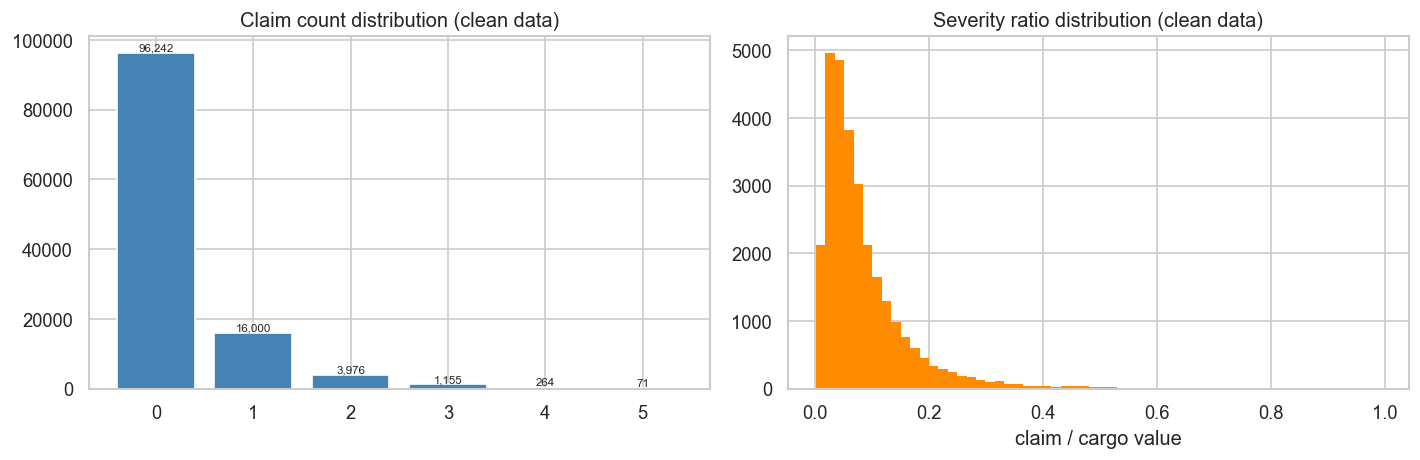

Clean frequency -- claim_count: {'count': 117708.0, 'mean': 0.24491113603153566, 'std': 0.5918969216151749, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 5.0}
Clean severity -- sev_ratio:   {'count': 28804.0, 'mean': 0.08537651073872479, 'std': 0.08283659097152805, 'min': 0.001369934150332735, '25%': 0.034756105887413964, '50%': 0.0608855278066979, '75%': 0.10637457843137255, 'max': 0.9924855284552846}


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc = freq_clean['claim_count'].value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color='steelblue', edgecolor='white')
axes[0].set_title('Claim count distribution (clean data)')
for val in vc.index:
    axes[0].annotate(f'{vc[val]:,}', xy=(val, vc[val]), ha='center', va='bottom', fontsize=7)
axes[1].hist(sev_clean['severity_ratio'], bins=60, color='darkorange', edgecolor='none')
axes[1].set_title('Severity ratio distribution (clean data)')
axes[1].set_xlabel('claim / cargo value')
plt.tight_layout(); plt.show()

print('Clean frequency -- claim_count:', freq_clean['claim_count'].describe().to_dict())
print('Clean severity -- sev_ratio:  ', sev_clean['severity_ratio'].describe().to_dict())

---
## 2. Exploratory Data Analysis (Clean Data)

### 2.1 Distribution of Numeric Features

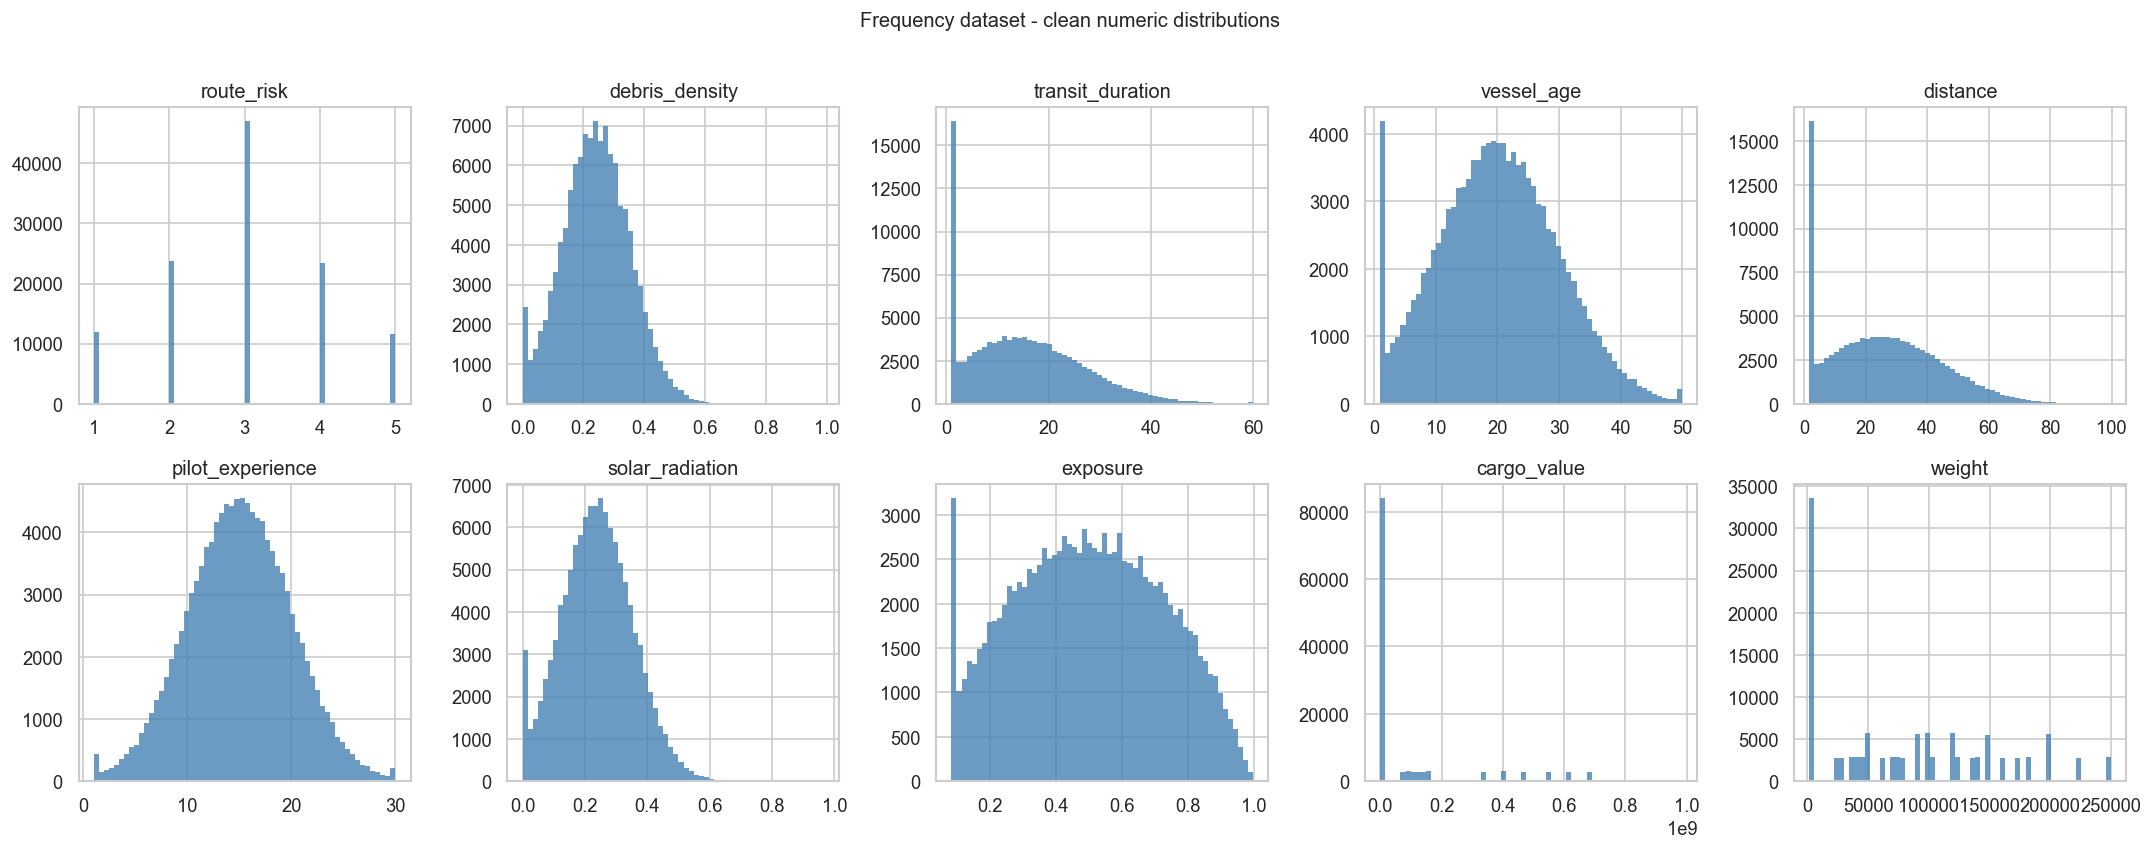

In [12]:
num_cols = ['route_risk', 'debris_density', 'transit_duration', 'vessel_age',
            'distance', 'pilot_experience', 'solar_radiation', 'exposure',
            'cargo_value', 'weight']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    data = freq_clean[col].dropna()
    axes[i].hist(data, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col)
plt.suptitle('Frequency dataset - clean numeric distributions', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 2.2 Claim Count Distribution

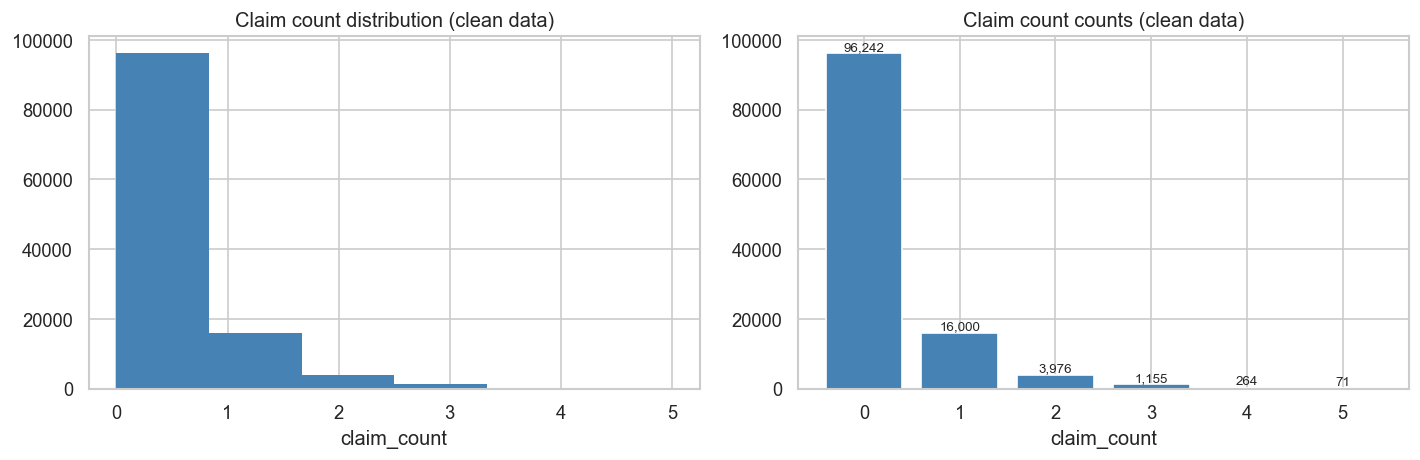

Claim count: {'count': 117708.0, 'mean': 0.24491113603153566, 'std': 0.5918969216151749, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 5.0}


In [13]:
cc = freq_clean['claim_count']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(cc, bins=cc.max()+1, color='steelblue', edgecolor='none')
axes[0].set_title('Claim count distribution (clean data)')
axes[0].set_xlabel('claim_count')

vc = cc.value_counts().sort_index()
axes[1].bar(vc.index, vc.values, color='steelblue', edgecolor='white')
for val in vc.index:
    axes[1].annotate(f'{vc[val]:,}', xy=(val, vc[val]), ha='center', va='bottom', fontsize=8)
axes[1].set_title('Claim count counts (clean data)')
axes[1].set_xlabel('claim_count')
plt.tight_layout()
plt.show()

print(f'Claim count: {cc.describe().to_dict()}')

Assuming that each individual claim is independent, we are able to model claim frequency as a Negative Binomial distribution.

### 2.3 Severity Ratio Distribution

`severity_ratio = claim_amount / cargo_value`.
As per data dictionary, max claim amount is strictly less than max cargo value.\
**ASSUMPTION**: claim amount is always less than cargo value.

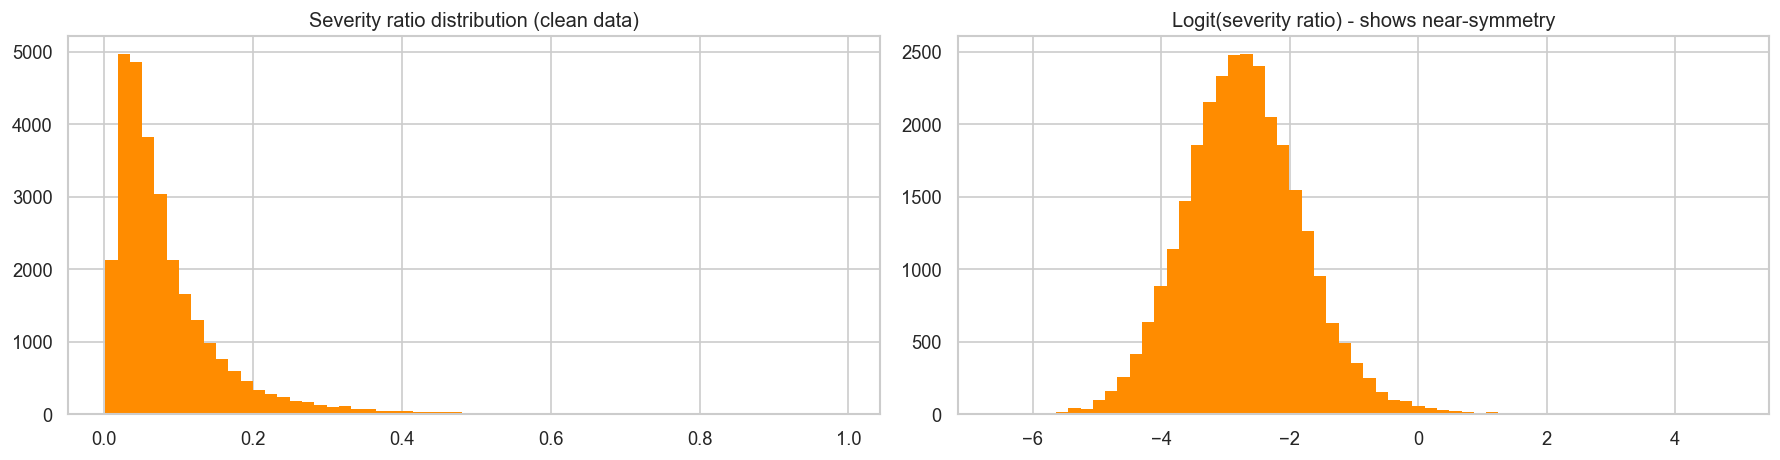

Severity ratio: n=28,804  mean=0.0854  median=0.0609


In [14]:
sr_valid = sev_clean['severity_ratio']

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].hist(sr_valid, bins=60, color='darkorange', edgecolor='none')
axes[0].set_title('Severity ratio distribution (clean data)')
axes[1].hist(np.log(sr_valid / (1 - sr_valid)), bins=60, color='darkorange', edgecolor='none')
axes[1].set_title('Logit(severity ratio) - shows near-symmetry')
plt.tight_layout()
plt.show()

print(f'Severity ratio: n={len(sr_valid):,}  mean={sr_valid.mean():.4f}  median={sr_valid.median():.4f}')

Claim severity ratio can be accurately modelled using a **beta** distribution, a RV between 0 and 1. We can confirm this by the symmetric bell shape of the severity ratio under the Logit function.

### 2.4 Categorical Features

Cargo and containers are evenly distributed - with a few incorrect entries that have been filtered out (For example, *DockArc Freight Case_???7673*)

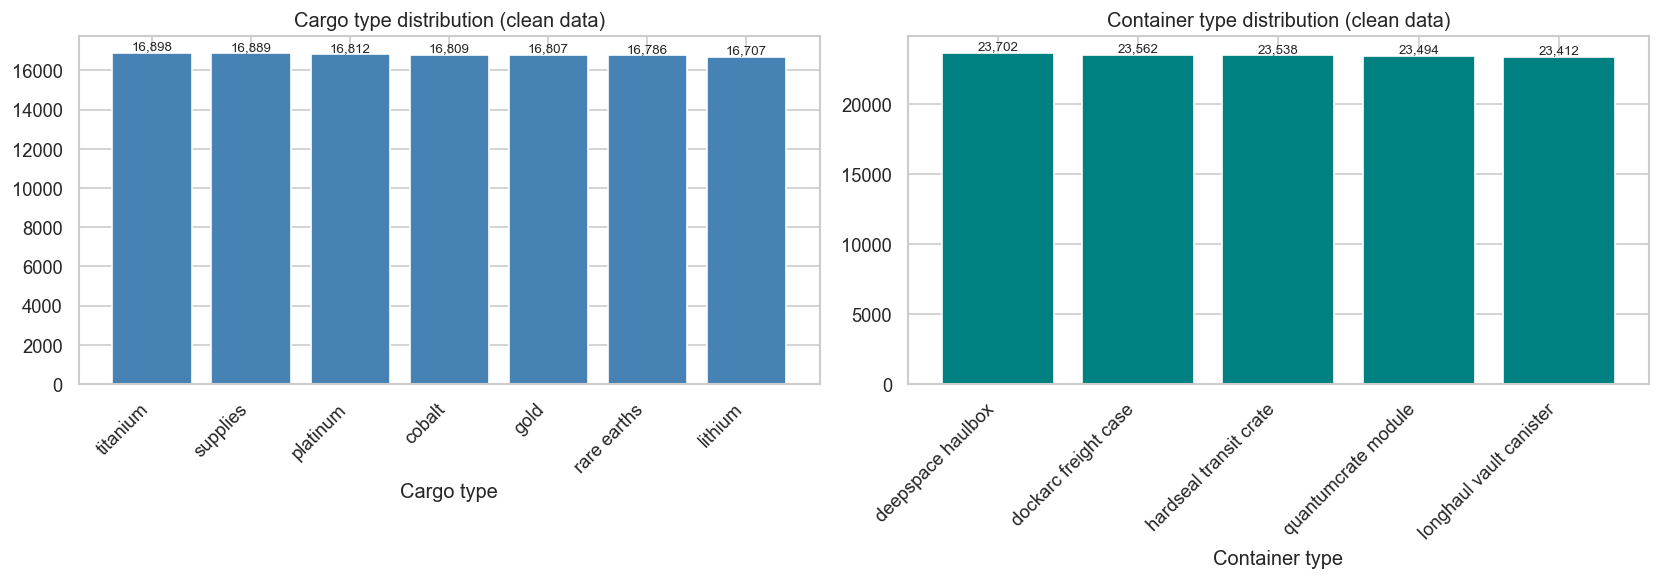

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vc_cargo = freq_clean['cargo_type'].str.strip().str.lower().value_counts()
axes[0].bar(range(len(vc_cargo)), vc_cargo.values, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(len(vc_cargo)))
axes[0].set_xticklabels(vc_cargo.index, rotation=45, ha='right')
for j, (cat, cnt) in enumerate(vc_cargo.items()):
    axes[0].text(j, cnt, f'{cnt:,}', ha='center', va='bottom', fontsize=8)
axes[0].set_title('Cargo type distribution (clean data)')
axes[0].set_xlabel('Cargo type')

vc_cont = freq_clean['container_type'].str.strip().str.lower().value_counts()
axes[1].bar(range(len(vc_cont)), vc_cont.values, color='teal', edgecolor='white')
axes[1].set_xticks(range(len(vc_cont)))
axes[1].set_xticklabels(vc_cont.index, rotation=45, ha='right')
for j, (cat, cnt) in enumerate(vc_cont.items()):
    axes[1].text(j, cnt, f'{cnt:,}', ha='center', va='bottom', fontsize=8)
axes[1].set_title('Container type distribution (clean data)')
axes[1].set_xlabel('Container type')

plt.tight_layout()
plt.show()

### 2.5 Predictor vs Claim Rate (Clean Data)

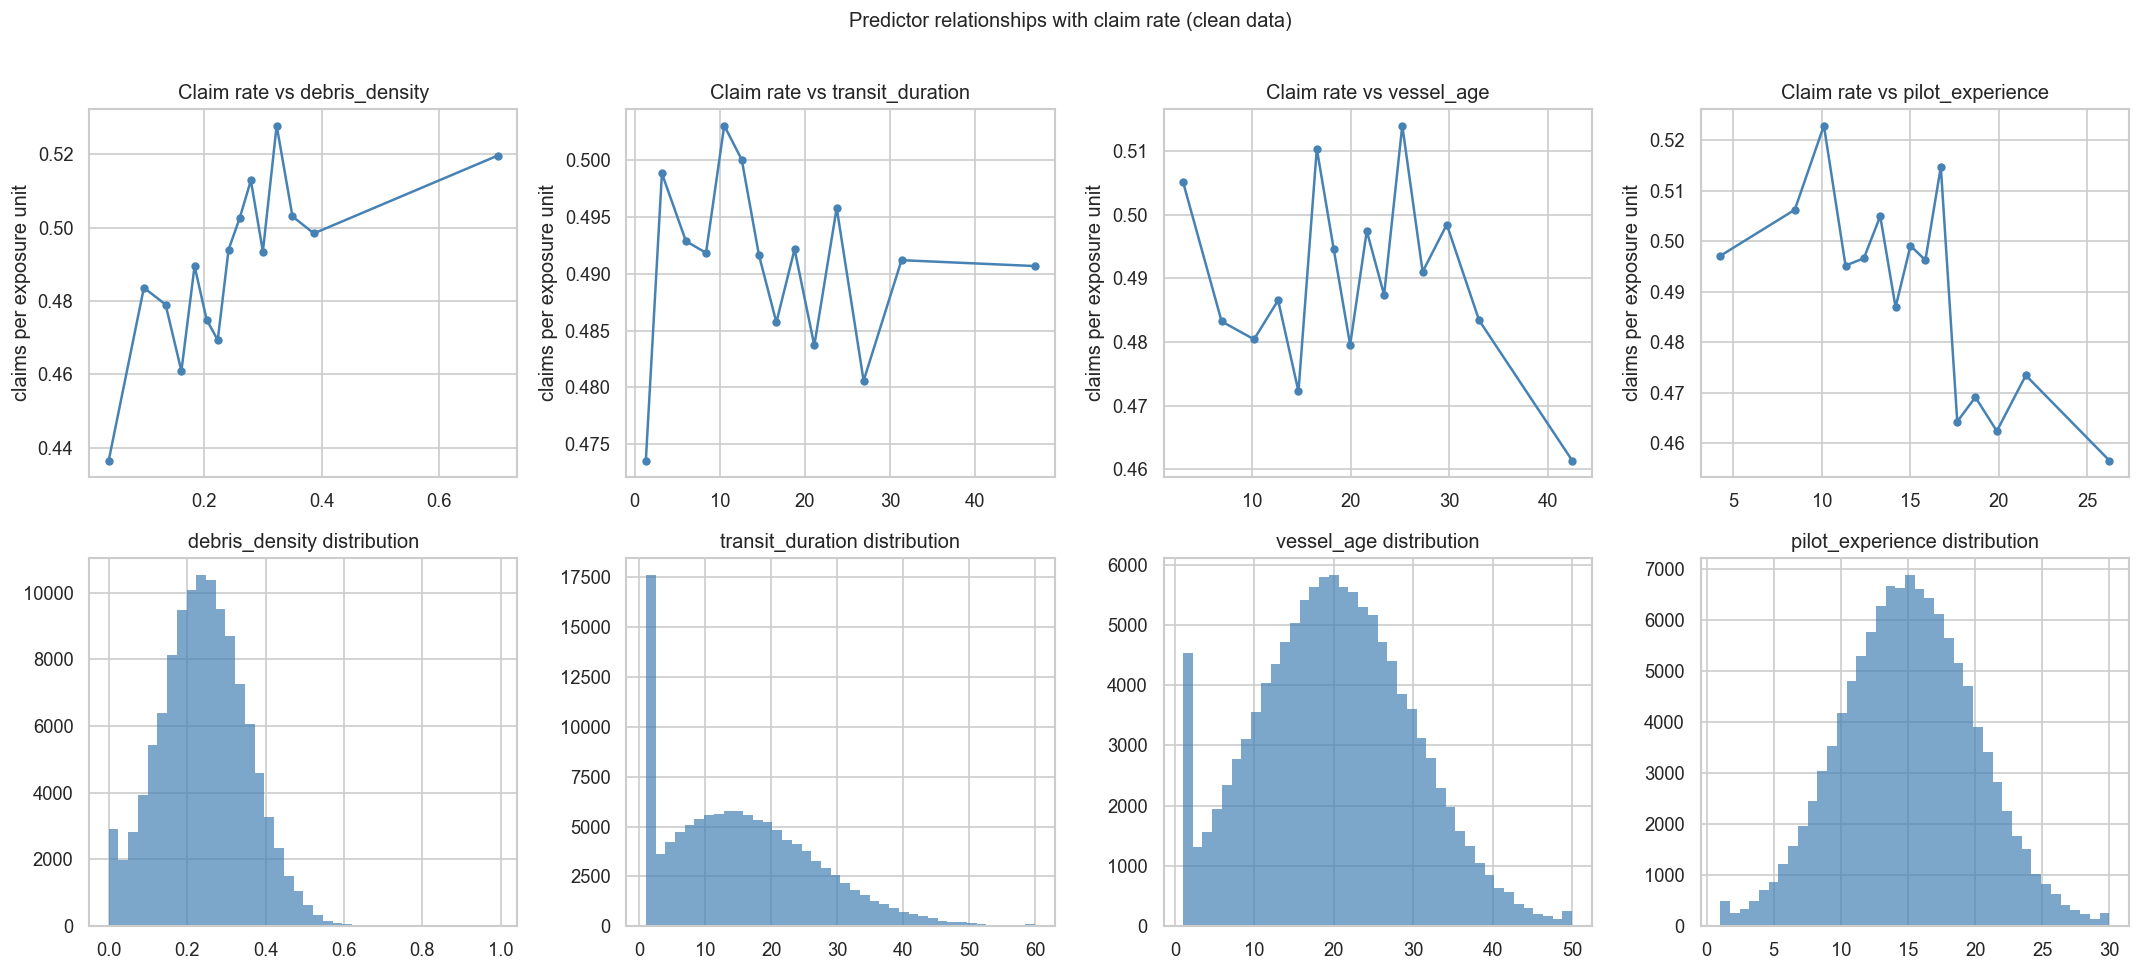

In [16]:

cont_preds = ['debris_density', 'transit_duration', 'vessel_age', 'pilot_experience']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(cont_preds):
    sub = freq_clean.copy()
    sub['bin'] = pd.qcut(sub[col], q=15, duplicates='drop')
    grp = sub.groupby('bin', observed=True)[['claim_count', 'exposure']].sum()
    grp['claim_rate'] = grp['claim_count'] / grp['exposure']
    grp['mid'] = grp.index.map(lambda x: x.mid)
    axes[0, i].plot(grp['mid'], grp['claim_rate'], 'o-', color='steelblue', ms=4)
    axes[0, i].set_title(f'Claim rate vs {col}')
    axes[0, i].set_ylabel('claims per exposure unit')
    axes[1, i].hist(freq_clean[col], bins=40, color='steelblue', edgecolor='none', alpha=0.7)
    axes[1, i].set_title(f'{col} distribution')
plt.suptitle('Predictor relationships with claim rate (clean data)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


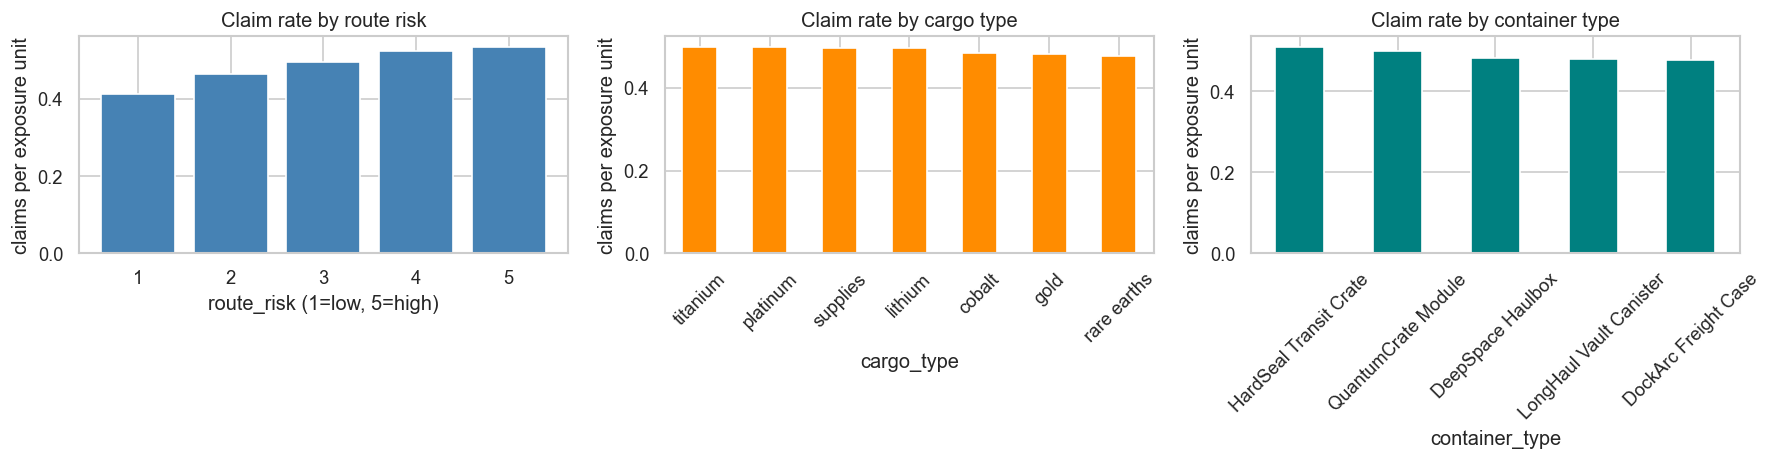

Route risk vs claim rate:
            claim_count      exposure  claim_rate
route_risk                                       
1.0                2464   5964.386774    0.413119
2.0                5506  11847.543810    0.464738
3.0               11620  23538.619000    0.493657
4.0                6110  11667.722346    0.523667
5.0                3128   5853.323543    0.534397


In [17]:

def agg_rate(df, group_col):
    g = df.groupby(group_col)[['claim_count', 'exposure']].sum()
    g['claim_rate'] = g['claim_count'] / g['exposure']
    return g['claim_rate']

rr_rate = freq_clean.groupby('route_risk')[['claim_count', 'exposure']].sum()
rr_rate['claim_rate'] = rr_rate['claim_count'] / rr_rate['exposure']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(rr_rate.index.astype(int), rr_rate['claim_rate'],
            color='steelblue', edgecolor='white')
axes[0].set_title('Claim rate by route risk')
axes[0].set_xlabel('route_risk (1=low, 5=high)')
axes[0].set_ylabel('claims per exposure unit')

ct_rate = agg_rate(freq_clean, 'cargo_type').sort_values(ascending=False)
ct_rate.plot.bar(ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Claim rate by cargo type')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('claims per exposure unit')

ctype_rate = agg_rate(freq_clean, 'container_type').sort_values(ascending=False)
ctype_rate.plot.bar(ax=axes[2], color='teal', edgecolor='white')
axes[2].set_title('Claim rate by container type')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylabel('claims per exposure unit')

plt.tight_layout()
plt.show()
print('Route risk vs claim rate:')
print(rr_rate[['claim_count', 'exposure', 'claim_rate']].to_string())


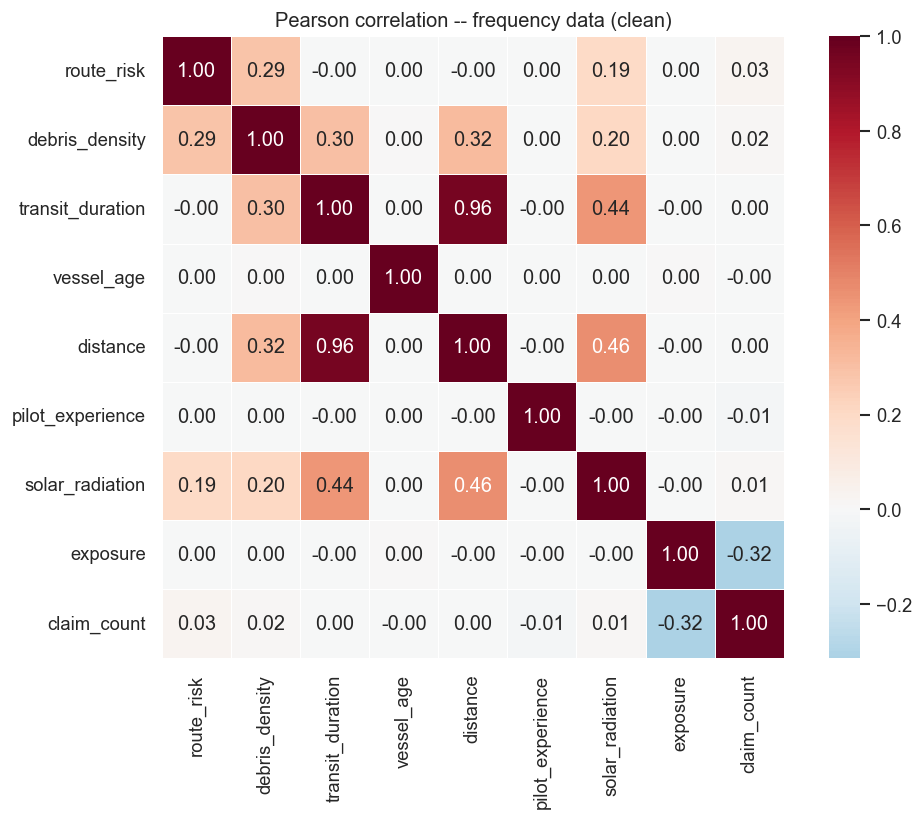

In [18]:

corr_cols = ['route_risk', 'debris_density', 'transit_duration', 'vessel_age',
             'distance', 'pilot_experience', 'solar_radiation', 'exposure', 'claim_count']
corr = freq_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Pearson correlation -- frequency data (clean)')
plt.tight_layout()
plt.show()


### 2.6 Severity Ratio vs Predictors (Clean Data)

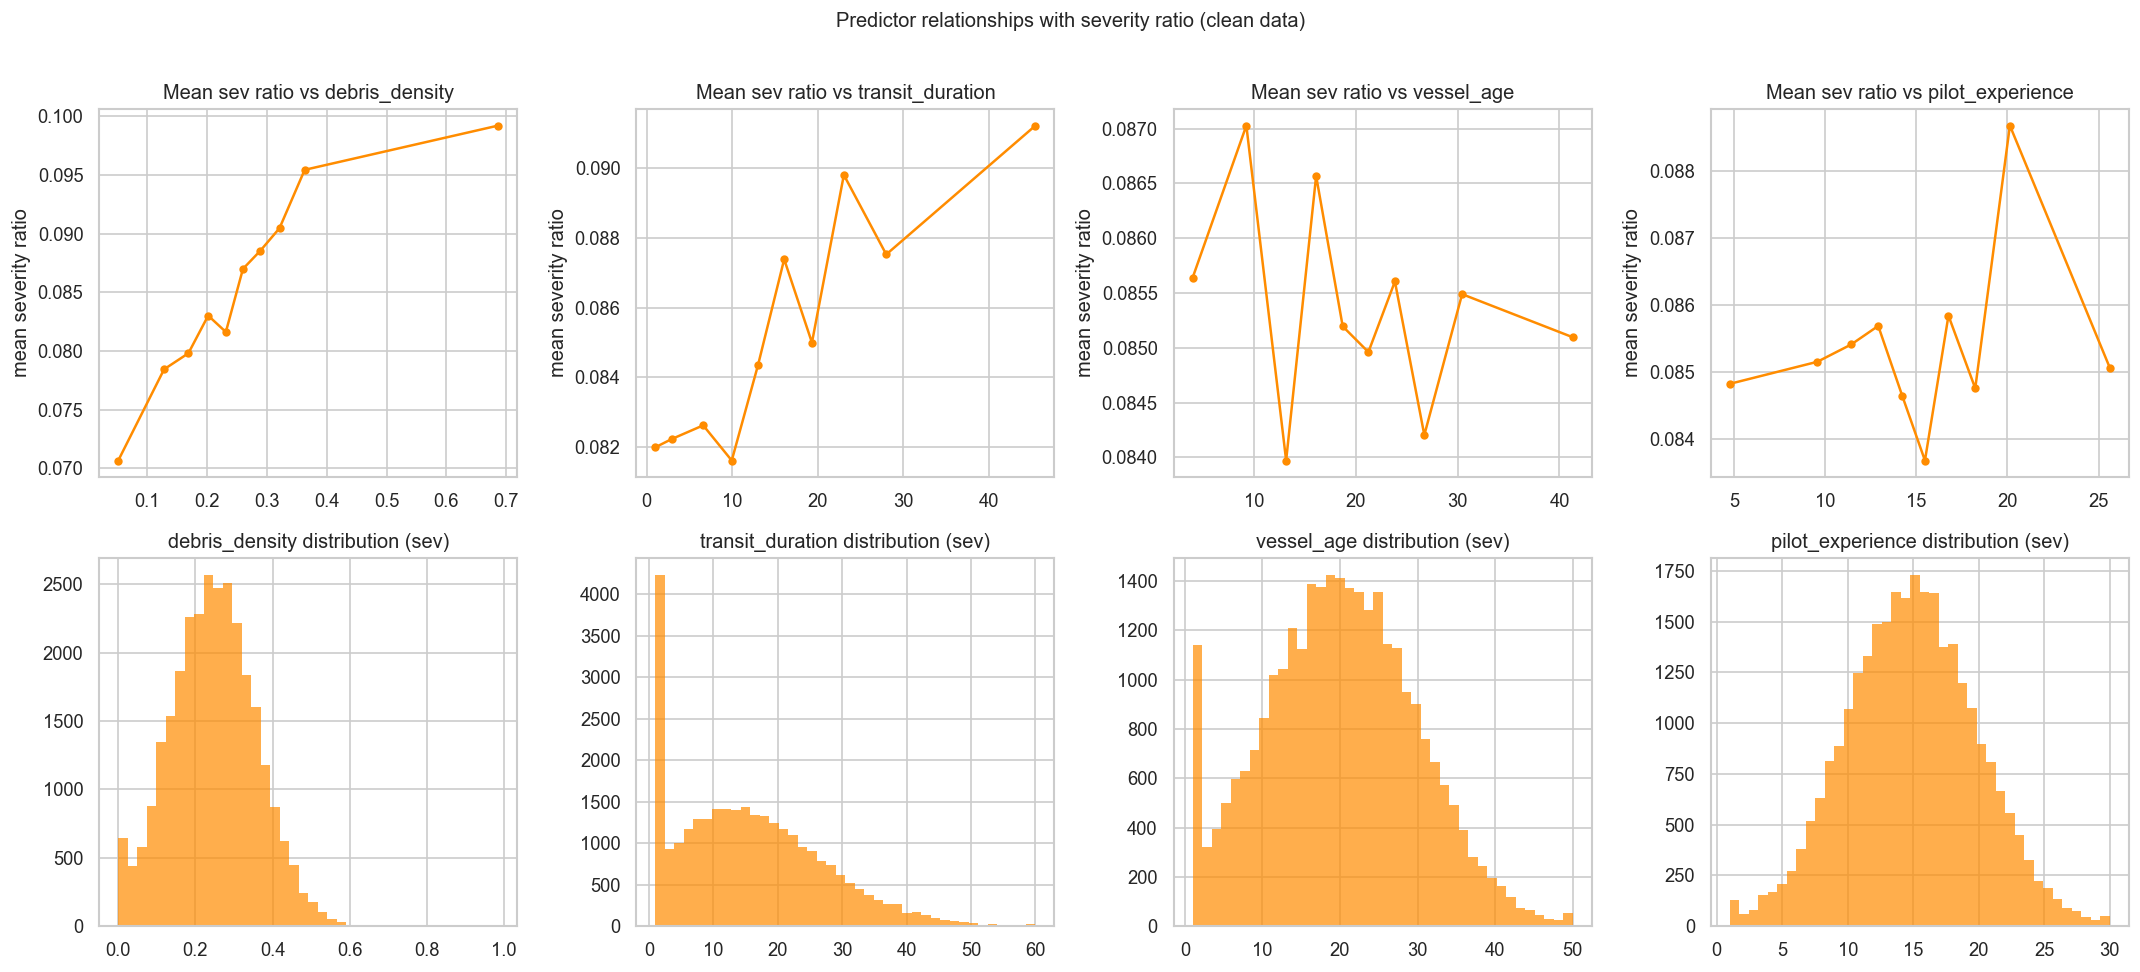

In [19]:

cont_preds = ['debris_density', 'transit_duration', 'vessel_age', 'pilot_experience']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(cont_preds):
    sub = sev_clean.copy()
    sub['bin'] = pd.qcut(sub[col], q=10, duplicates='drop')
    grp = sub.groupby('bin', observed=True)['severity_ratio'].mean().reset_index()
    grp['mid'] = grp['bin'].apply(lambda x: x.mid)
    axes[0, i].plot(grp['mid'], grp['severity_ratio'], 'o-', color='darkorange', ms=4)
    axes[0, i].set_title(f'Mean sev ratio vs {col}')
    axes[0, i].set_ylabel('mean severity ratio')
    axes[1, i].hist(sev_clean[col], bins=40, color='darkorange', edgecolor='none', alpha=0.7)
    axes[1, i].set_title(f'{col} distribution (sev)')
plt.suptitle('Predictor relationships with severity ratio (clean data)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


Route risk vs severity ratio:
                mean    median  count
route_risk                           
1.0         0.052999  0.037609   2481
2.0         0.068717  0.049487   5496
3.0         0.085118  0.061823  11615
4.0         0.097995  0.071724   6068
5.0         0.116648  0.084462   3144


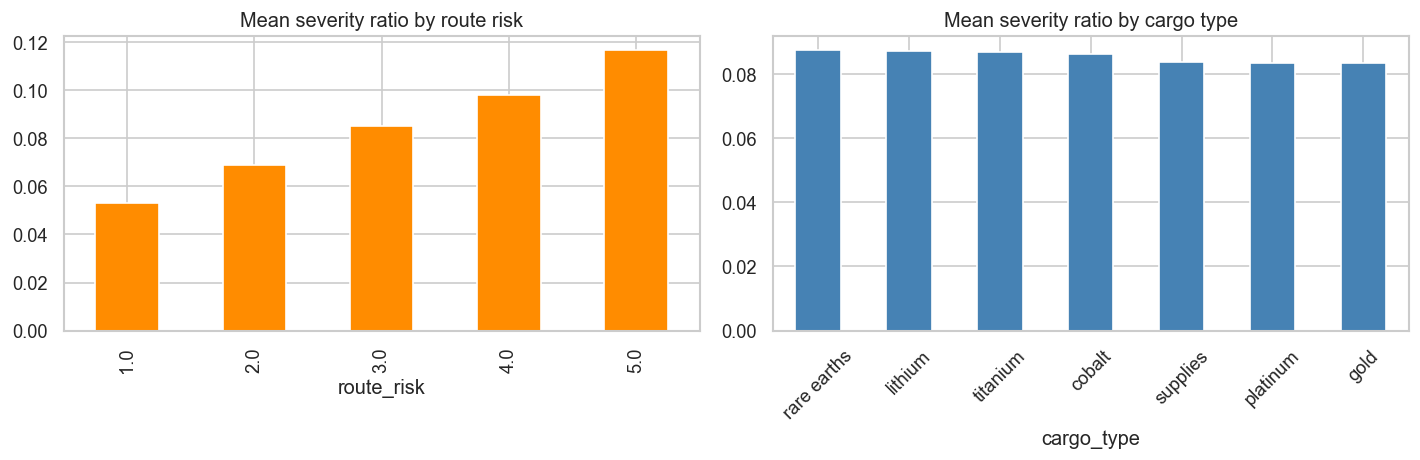

In [20]:

rr_sev = sev_clean.groupby('route_risk')['severity_ratio'].agg(['mean', 'median', 'count'])
print('Route risk vs severity ratio:')
print(rr_sev.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rr_sev['mean'].plot.bar(ax=axes[0], color='darkorange', edgecolor='white')
axes[0].set_title('Mean severity ratio by route risk')

cargo_sev = sev_clean.groupby('cargo_type')['severity_ratio'].mean().sort_values(ascending=False)
cargo_sev.plot.bar(ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Mean severity ratio by cargo type')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


---
## 3. Frequency Model -- Negative Binomial GLM

Negative binomial distribution was selected over a Poisson distribution, due to a Poisson distribution producing a dispersion level of 4.51.

**Features**
- Features have been selected from notable trends during EDA, and identifying statistically significant covariates.
- Claim probability does not increase as a function of distance, travel time, or exposure.
- Notably, claim probability a function of route risk, debris, solar radiation, and not on route distance. This suggests that significant risk comes from specific key hazards along the route, like periods close to the Sun, or travelling through debris fields.


**Specification:**

$$\log(E[N_i]) = \log(\text{exposure}_i) + \beta_0 + \sum_{k=2}^{5}\beta_{\text{RR}=k}\,\mathbf{1}[\text{RR}_i=k] + \sum_j \beta_{\text{cargo},j}\,\mathbf{1}[\text{cargo}_i=j] + \sum_l \beta_{\text{cont},l}\,\mathbf{1}[\text{cont}_i=l] + \beta_\text{debris}\,z_{\text{debris},i} + \beta_\text{pilot}\,z_{\text{pilot},i} + \beta_\text{solar}\,z_{\text{solar},i}$$

- **Response:** `claim_count` ~ Negative Binomial  
- **Offset:** $\log(\text{exposure})$  
- **`route_risk`** -- categorical, levels 1--5 (reference = 1)  
- **`cargo_type`** -- categorical, 7 levels (reference = supplies)  
- **`container_type`** -- categorical, 5 levels (reference = longhaul vault canister)  
- Continuous predictors z-score standardised for numerical stability

In [21]:
freq_model_df = freq_clean.copy()
freq_model_df['log_exposure'] = np.log(freq_model_df['exposure'])
freq_model_df['route_risk_cat'] = pd.Categorical(
    freq_model_df['route_risk'].astype(int).astype(str),
    categories=['1','2','3','4','5'], ordered=True
)

# Categorical predictors (normalise case to match whitelists)
freq_model_df['cargo_type_cat']     = freq_model_df['cargo_type'].str.strip().str.lower()
freq_model_df['container_type_cat'] = freq_model_df['container_type'].str.strip().str.lower()

# Collapse non-significant container types into reference level
_merge_containers = {'deepspace haulbox', 'dockarc freight case'}
freq_model_df['container_type_cat'] = freq_model_df['container_type_cat'].apply(
    lambda x: 'longhaul vault canister' if x in _merge_containers else x
)

# Standardise continuous predictors
freq_std = {}
for col in ['debris_density', 'pilot_experience', 'solar_radiation']:
    mu = freq_model_df[col].mean()
    sd = freq_model_df[col].std()
    freq_std[col] = {'mean': mu, 'std': sd}
    freq_model_df[f'{col}_z'] = (freq_model_df[col] - mu) / sd
    print(f'{col}: mean={mu:.4f}, std={sd:.4f}')

# Drop rows missing any model variable
mvars_freq = ['claim_count', 'exposure', 'route_risk', 'debris_density',
              'pilot_experience', 'solar_radiation',
              'cargo_type_cat', 'container_type_cat']
freq_model_df = freq_model_df.dropna(subset=mvars_freq)
print(f'\nFrequency model rows: {len(freq_model_df):,}')

debris_density: mean=0.2425, std=0.1097
pilot_experience: mean=15.0072, std=4.9903
solar_radiation: mean=0.2391, std=0.1140

Frequency model rows: 117,708


In [22]:
freq_formula = (
    'claim_count ~ C(route_risk_cat, Treatment(reference="1"))'
    ' + C(container_type_cat, Treatment(reference="longhaul vault canister"))'
    ' + debris_density_z + pilot_experience_z + solar_radiation_z'
)

freq_glm = smf.glm(
    formula=freq_formula,
    data=freq_model_df,
    family=sm.families.NegativeBinomial()
).fit()
print(freq_glm.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:               117708
Model:                            GLM   Df Residuals:                   117698
Model Family:        NegativeBinomial   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -72577.
Date:                Sun, 08 Mar 2026   Deviance:                       78707.
Time:                        10:52:33   Pearson chi2:                 1.36e+05
No. Iterations:                     5   Pseudo R-squ. (CS):           0.001369
Covariance Type:            nonrobust                                         
                                                                                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

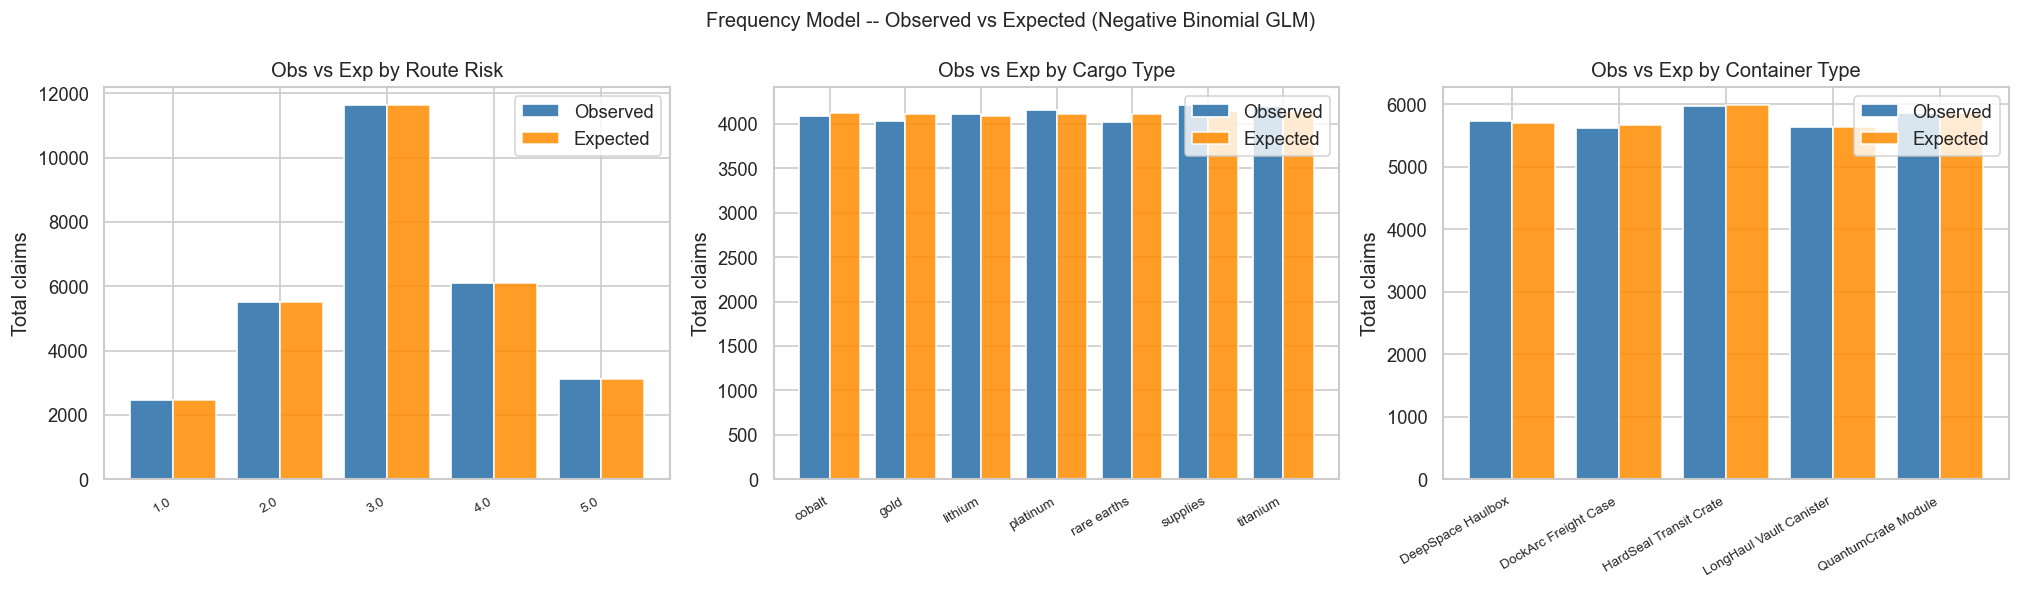

In [23]:
freq_model_df['fitted_mu'] = freq_glm.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col, title in zip(axes,
        ['route_risk', 'cargo_type', 'container_type'],
        ['Route Risk', 'Cargo Type', 'Container Type']):
    grp = freq_model_df.groupby(col).agg(
        obs=('claim_count', 'sum'), exp=('fitted_mu', 'sum')
    ).reset_index()
    x = np.arange(len(grp))
    ax.bar(x - 0.2, grp['obs'], 0.4, label='Observed', color='steelblue')
    ax.bar(x + 0.2, grp['exp'], 0.4, label='Expected', color='darkorange', alpha=0.85)
    ax.set_xticks(x)
    labels = grp[col].astype(str)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_title(f'Obs vs Exp by {title}')
    ax.set_ylabel('Total claims')
    ax.legend()

plt.suptitle(f'Frequency Model -- Observed vs Expected (Negative Binomial GLM)', fontsize=12)
plt.tight_layout()
plt.show()

Incidence Rate Ratios (IRR = exp(coef)):
                                                                                                   coef     IRR  IRR_lb  IRR_ub  p_value
Intercept                                                                                       -1.5829  0.2054  0.1963  0.2149   0.0000
C(route_risk_cat, Treatment(reference="1"))[T.2]                                                 0.1094  1.1156  1.0586  1.1758   0.0000
C(route_risk_cat, Treatment(reference="1"))[T.3]                                                 0.1646  1.1790  1.1231  1.2377   0.0000
C(route_risk_cat, Treatment(reference="1"))[T.4]                                                 0.2171  1.2425  1.1782  1.3102   0.0000
C(route_risk_cat, Treatment(reference="1"))[T.5]                                                 0.2345  1.2643  1.1897  1.3435   0.0000
C(container_type_cat, Treatment(reference="longhaul vault canister"))[T.hardseal transit crate]  0.0549  1.0564  1.0222  1.0918   0.0011


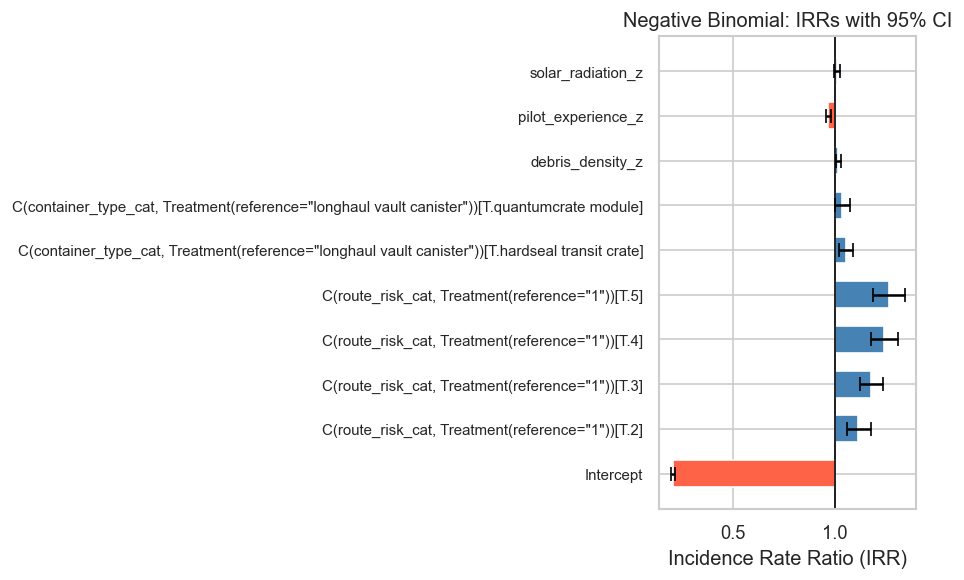

In [24]:
coef_df = pd.DataFrame({
    'coef':    freq_glm.params,
    'IRR':     np.exp(freq_glm.params),
    'IRR_lb':  np.exp(freq_glm.conf_int()[0]),
    'IRR_ub':  np.exp(freq_glm.conf_int()[1]),
    'p_value': freq_glm.pvalues
})
print('Incidence Rate Ratios (IRR = exp(coef)):')
print(coef_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(coef_df))
ax.barh(y_pos, coef_df['IRR']-1, left=1,
        color=['steelblue' if v>0 else 'tomato' for v in (coef_df['IRR']-1)],
        edgecolor='white', height=0.6)
ax.errorbar(coef_df['IRR'], y_pos,
            xerr=[coef_df['IRR']-coef_df['IRR_lb'], coef_df['IRR_ub']-coef_df['IRR']],
            fmt='none', color='black', capsize=4, lw=1.5)
ax.axvline(1, color='black', lw=1)
ax.set_yticks(y_pos); ax.set_yticklabels(coef_df.index, fontsize=9)
ax.set_xlabel('Incidence Rate Ratio (IRR)')
ax.set_title('Negative Binomial: IRRs with 95% CI')
plt.tight_layout(); plt.show()

---
## 4. Severity Model -- Beta Regression

**Specification:**

$$\text{logit}(\mu_i) = \gamma_0 + \sum_{k=2}^{5}\gamma_{\text{RR}=k}\,\mathbf{1}[\text{RR}_i=k] + \sum_j \gamma_{\text{cargo},j}\,\mathbf{1}[\text{cargo}_i=j] + \sum_l \gamma_{\text{cont},l}\,\mathbf{1}[\text{cont}_i=l] + \gamma_\text{debris}\,z_{\text{debris},i} + \gamma_\text{transit}\,z_{\text{transit},i} + \gamma_\text{pilot}\,z_{\text{pilot},i} + \gamma_\text{solar}\,z_{\text{solar},i}$$

where $S_i = \text{claim}_i / V_i \sim \text{Beta}(\mu_i\phi,\,(1-\mu_i)\phi)$ and $\phi$ is the precision parameter.

- **Response:** `severity_ratio` $\in (0,1)$  
- **`route_risk`** -- categorical, levels 1--5 (reference = 1)  
- **`cargo_type`** -- categorical, 7 levels (reference = supplies)  
- **`container_type`** -- categorical, 5 levels (reference = longhaul vault canister)  
- Continuous predictors z-score standardised for numerical stability

In [25]:
sev_model_df = sev_clean.copy()
sev_model_df['route_risk_cat'] = pd.Categorical(
    sev_model_df['route_risk'].astype(int).astype(str),
    categories=['1','2','3','4','5'], ordered=True
)

# Standardise continuous predictors
sev_std = {}
for col in ['debris_density', 'solar_radiation']:
    mu = sev_model_df[col].mean()
    sd = sev_model_df[col].std()
    sev_std[col] = {'mean': mu, 'std': sd}
    sev_model_df[f'{col}_z'] = (sev_model_df[col] - mu) / sd

# Drop rows missing any model variable
mvars_sev = ['severity_ratio', 'route_risk', 'debris_density', 'solar_radiation']
sev_model_df = sev_model_df.dropna(subset=mvars_sev)

print(f'Severity model rows: {len(sev_model_df):,}')
print(f'severity_ratio: [{sev_model_df["severity_ratio"].min():.6f}, '
      f'{sev_model_df["severity_ratio"].max():.6f}]')

Severity model rows: 28,804
severity_ratio: [0.001370, 0.992486]


In [26]:
sev_formula = (
    'severity_ratio ~ C(route_risk_cat, Treatment(reference="1"))'
    ' + debris_density_z + solar_radiation_z'
)

y_sev, X_sev = dmatrices(sev_formula, data=sev_model_df, return_type='dataframe')
y_sev_arr = y_sev.values.ravel()

sev_beta = BetaModel(y_sev_arr, X_sev).fit(disp=False)
print(sev_beta.summary())

                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 43366.
Model:                      BetaModel   AIC:                        -8.672e+04
Method:            Maximum Likelihood   BIC:                        -8.665e+04
Date:                Sun, 08 Mar 2026                                         
Time:                        10:52:34                                         
No. Observations:               28804                                         
Df Residuals:                   28796                                         
Df Model:                           6                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                                           -2.

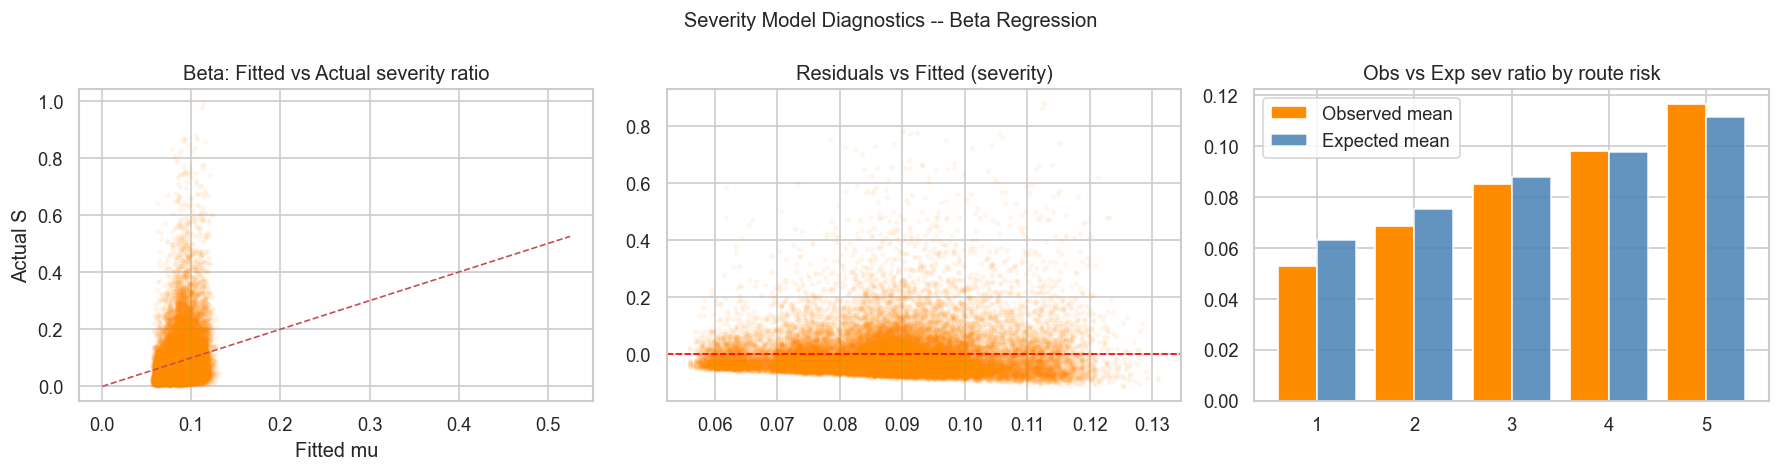

In [27]:
sev_model_df['fitted_mu_sev'] = sev_beta.predict()
sev_model_df['resid_sev']     = sev_model_df['severity_ratio'] - sev_model_df['fitted_mu_sev']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

lim_s = sev_model_df['severity_ratio'].quantile(0.995)
axes[0].scatter(sev_model_df['fitted_mu_sev'], sev_model_df['severity_ratio'],
                alpha=0.05, s=5, color='darkorange')
axes[0].plot([0, lim_s], [0, lim_s], 'r--', lw=1)
axes[0].set_title('Beta: Fitted vs Actual severity ratio')
axes[0].set_xlabel('Fitted mu'); axes[0].set_ylabel('Actual S')

axes[1].scatter(sev_model_df['fitted_mu_sev'], sev_model_df['resid_sev'],
                alpha=0.05, s=5, color='darkorange')
axes[1].axhline(0, color='red', lw=1, ls='--')
axes[1].set_title('Residuals vs Fitted (severity)')

grp_s = sev_model_df.groupby('route_risk').agg(
    obs=('severity_ratio', 'mean'), exp=('fitted_mu_sev', 'mean')
).reset_index()
x = np.arange(len(grp_s))
axes[2].bar(x-0.2, grp_s['obs'], 0.4, label='Observed mean', color='darkorange')
axes[2].bar(x+0.2, grp_s['exp'], 0.4, label='Expected mean', color='steelblue', alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(grp_s['route_risk'].astype(int))
axes[2].set_title('Obs vs Exp sev ratio by route risk')
axes[2].legend()

plt.suptitle('Severity Model Diagnostics -- Beta Regression', fontsize=12)
plt.tight_layout(); plt.show()

Severity model -- coefficients (logit scale) and odds ratios:
                                                    coef      OR   OR_lb   OR_ub  p_value
Intercept                                        -2.6689  0.0693  0.0671  0.0716      0.0
C(route_risk_cat, Treatment(reference="1"))[T.2]  0.1724  1.1881  1.1442  1.2338      0.0
C(route_risk_cat, Treatment(reference="1"))[T.3]  0.3254  1.3846  1.3373  1.4337      0.0
C(route_risk_cat, Treatment(reference="1"))[T.4]  0.4288  1.5355  1.4793  1.5937      0.0
C(route_risk_cat, Treatment(reference="1"))[T.5]  0.5610  1.7523  1.6817  1.8260      0.0
debris_density_z                                  0.0287  1.0291  1.0199  1.0384      0.0
solar_radiation_z                                 0.0422  1.0431  1.0340  1.0522      0.0

Precision phi = 16.6942


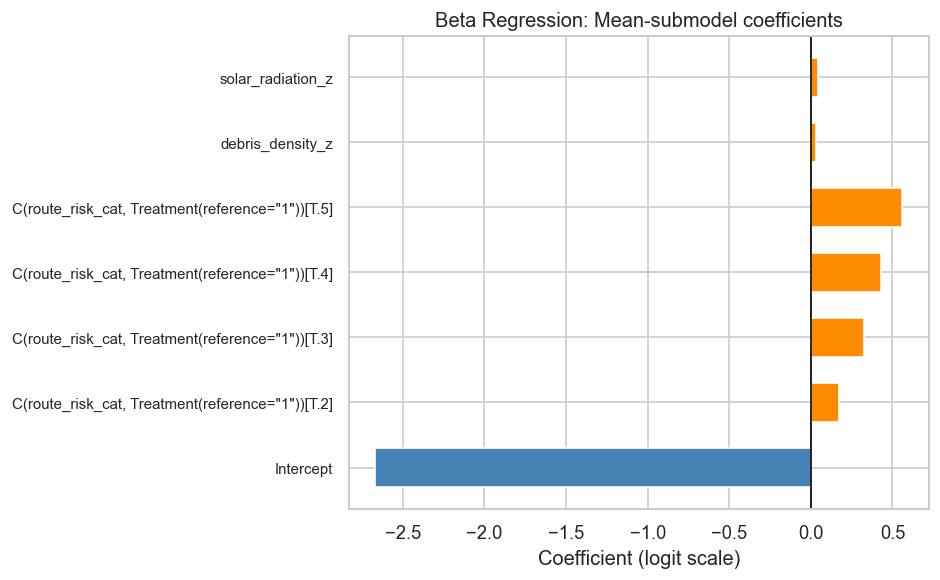

In [28]:
n_mean = X_sev.shape[1]
mean_params = sev_beta.params[:n_mean]
phi_param   = sev_beta.params[n_mean:]
ci_mean     = sev_beta.conf_int().iloc[:n_mean]

coef_sev_df = pd.DataFrame({
    'coef':    mean_params.values,
    'OR':      np.exp(mean_params.values),
    'OR_lb':   np.exp(ci_mean.iloc[:, 0].values),
    'OR_ub':   np.exp(ci_mean.iloc[:, 1].values),
    'p_value': sev_beta.pvalues[:n_mean].values
}, index=X_sev.columns)

print('Severity model -- coefficients (logit scale) and odds ratios:')
print(coef_sev_df.round(4).to_string())
print(f'\nPrecision phi = {np.exp(phi_param.values[0]):.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(coef_sev_df))
ax.barh(y_pos, coef_sev_df['coef'],
        color=['darkorange' if v>0 else 'steelblue' for v in coef_sev_df['coef']],
        edgecolor='white', height=0.6)
ax.axvline(0, color='black', lw=1)
ax.set_yticks(y_pos); ax.set_yticklabels(coef_sev_df.index, fontsize=9)
ax.set_xlabel('Coefficient (logit scale)')
ax.set_title('Beta Regression: Mean-submodel coefficients')
plt.tight_layout(); plt.show()

---
## 5. Pricing

**Pure premium rate** (fraction of cargo value):

$$\text{Rate}_i = E[N_i \mid X_i] \times E[S_i \mid X_i]$$

**Gross premium rate** with combined loading $L$:

$$\text{Gross Rate}_i = \frac{\text{Rate}_i}{1 - e - p - r}$$

where $e$ = expense ratio, $p$ = profit margin, $r$ = risk/uncertainty loading.

In [29]:
def predict_freq_rate(route_risk, debris_density, pilot_experience, solar_radiation,
                     cargo_type='supplies', container_type='longhaul vault canister'):
    row = pd.DataFrame([{
        'route_risk_cat': pd.Categorical([str(int(route_risk))],
                          categories=['1','2','3','4','5'], ordered=True)[0],
        'cargo_type_cat':     cargo_type.strip().lower(),
        'container_type_cat': container_type.strip().lower(),
        'debris_density_z':   (debris_density   - freq_std['debris_density']['mean'])   / freq_std['debris_density']['std'],
        'pilot_experience_z': (pilot_experience - freq_std['pilot_experience']['mean']) / freq_std['pilot_experience']['std'],
        'solar_radiation_z':  (solar_radiation  - freq_std['solar_radiation']['mean'])  / freq_std['solar_radiation']['std'],
    }])
    return freq_glm.predict(row).values[0]

def predict_sev_ratio(route_risk, debris_density, solar_radiation):
    row = pd.DataFrame([{
        'route_risk_cat': pd.Categorical([str(int(route_risk))],
                          categories=['1','2','3','4','5'], ordered=True)[0],
        'debris_density_z':  (debris_density  - sev_std['debris_density']['mean'])  / sev_std['debris_density']['std'],
        'solar_radiation_z': (solar_radiation - sev_std['solar_radiation']['mean']) / sev_std['solar_radiation']['std'],
    }])
    X_new = dmatrix(X_sev.design_info, data=row, return_type='dataframe')
    return sev_beta.predict(exog=X_new).values[0]

# Representative profiles: median continuous predictors per route risk
freq_stats = freq_model_df.groupby('route_risk').agg(
    dd_med=('debris_density',   'median'),
    pe_med=('pilot_experience', 'median'),
    sr_med=('solar_radiation',  'median'),
).reset_index()
print('Representative profiles by route risk:')
print(freq_stats.to_string(index=False))

Representative profiles by route risk:
 route_risk  dd_med  pe_med  sr_med
        1.0   0.183 15.0270   0.196
        2.0   0.212 15.0425   0.217
        3.0   0.242 14.9490   0.238
        4.0   0.272 15.0645   0.258
        5.0   0.299 15.0220   0.277


In [30]:
EXPENSE_RATIO = 0.15
PROFIT_MARGIN = 0.10
RISK_LOADING  = 0.05
TOTAL_LOADING = 1 / (1 - EXPENSE_RATIO - PROFIT_MARGIN - RISK_LOADING)
EXAMPLE_CARGO = 10_000_000

rows = []
for _, r in freq_stats.iterrows():
    rr = int(r['route_risk'])
    dd, pe, sr = r['dd_med'], r['pe_med'], r['sr_med']
    fr  = predict_freq_rate(rr, dd, pe, sr)
    sv  = predict_sev_ratio(rr, dd, sr)
    pr  = fr * sv
    rows.append({
        'route_risk':         rr,
        'expected_freq':      fr,
        'expected_sev_ratio': sv,
        'pure_rate_%':        pr * 100,
        'gross_rate_%':       pr * TOTAL_LOADING * 100,
        'pure_prem_$10M':     pr * EXAMPLE_CARGO,
        'gross_prem_$10M':    pr * TOTAL_LOADING * EXAMPLE_CARGO,
    })

rating_table = pd.DataFrame(rows)
print(f'Loading: expense={EXPENSE_RATIO:.0%}, profit={PROFIT_MARGIN:.0%}, '
      f'risk={RISK_LOADING:.0%}  ->  multiplier={TOTAL_LOADING:.4f}x')
print()
cols_show = ['route_risk', 'expected_freq', 'expected_sev_ratio',
             'pure_rate_%', 'gross_rate_%', 'pure_prem_$10M', 'gross_prem_$10M']
print(rating_table[cols_show].to_string(index=False, float_format='{:.5f}'.format))

Loading: expense=15%, profit=10%, risk=5%  ->  multiplier=1.4286x

 route_risk  expected_freq  expected_sev_ratio  pure_rate_%  gross_rate_%  pure_prem_$10M  gross_prem_$10M
          1        0.20257             0.06282      1.27254       1.81791    127253.82316     181791.17594
          2        0.22748             0.07483      1.70218       2.43169    170218.01562     243168.59374
          3        0.24218             0.08738      2.11619       3.02313    211618.93127     302312.75896
          4        0.25676             0.09732      2.49886       3.56980    249885.66886     356979.52694
          5        0.26294             0.11095      2.91742       4.16775    291742.49103     416774.98719


In [31]:
print('=' * 65)
print('CARGO LOSS MODEL -- SUMMARY')
print('=' * 65)
print(f'\nFrequency Model : Negative Binomial')
print(f'  AIC            : {freq_glm.aic:.1f}')
print(f'  Observations   : {len(freq_model_df):,}')
print(f'  % with claim   : {(freq_model_df["claim_count"] > 0).mean()*100:.1f}%')
print()
print('Severity Model  : Beta Regression')
print(f'  AIC            : {sev_beta.aic:.1f}')
print(f'  Observations   : {len(sev_model_df):,}')
print(f'  Mean sev ratio : {sev_model_df["severity_ratio"].mean():.4f}')
print()
print('Pricing Parameters:')
print(f'  Expense ratio  : {EXPENSE_RATIO:.0%}')
print(f'  Profit margin  : {PROFIT_MARGIN:.0%}')
print(f'  Risk loading   : {RISK_LOADING:.0%}')
print(f'  Combined mult. : {TOTAL_LOADING:.3f}x')
print()
print('Indicative Gross Premium Rates (median risk profile per route risk):')
for _, row in rating_table.iterrows():
    rr = int(row['route_risk'])
    r  = row['gross_rate_%']
    p  = row['gross_prem_$10M']
    print(f'  Route Risk {rr}: {r:.4f}% of cargo value   '
          f'-> ${p:>12,.0f} on a $10M shipment')

CARGO LOSS MODEL -- SUMMARY

Frequency Model : Negative Binomial
  AIC            : 145174.2
  Observations   : 117,708
  % with claim   : 18.2%

Severity Model  : Beta Regression
  AIC            : -86715.3
  Observations   : 28,804
  Mean sev ratio : 0.0854

Pricing Parameters:
  Expense ratio  : 15%
  Profit margin  : 10%
  Risk loading   : 5%
  Combined mult. : 1.429x

Indicative Gross Premium Rates (median risk profile per route risk):
  Route Risk 1: 1.8179% of cargo value   -> $     181,791 on a $10M shipment
  Route Risk 2: 2.4317% of cargo value   -> $     243,169 on a $10M shipment
  Route Risk 3: 3.0231% of cargo value   -> $     302,313 on a $10M shipment
  Route Risk 4: 3.5698% of cargo value   -> $     356,980 on a $10M shipment
  Route Risk 5: 4.1677% of cargo value   -> $     416,775 on a $10M shipment
